<a href="https://colab.research.google.com/github/ava-yahyapour/ava-yahyapour/blob/main/DAIC_WOZ_Depression_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Depression Detection from Speech — DAIC-WOZ Pipeline
### Speech and Audio Understanding Course at CUNY
**Google Colab Notebook — Full Pipeline**

This notebook covers:
1. Environment setup
2. Download & organize DAIC-WOZ data
3. Explore labels (train/dev/test splits)
4. Parse transcripts & extract participant-only audio
5. Extract eGeMAPS features (System 1)
6. Extract Wav2Vec 2.0 embeddings (System 2)
7. Build fusion features (System 3)
8. Train & evaluate all models
9. Results comparison
10. Feature Importance Analysis — which of the 88 eGeMAPS features predict depression best
11. Hyperparameter Tuning — optimize the best performing models (SVR eGeMAPS + Logistic Regression Wav2Vec)
12. Attention-Weighted Fusion (System 4) — stacking meta-learner that learns optimal combination of both systems


## Section 1 — Install & Import All Dependencies

In [ ]:
# Install required libraries
!pip install opensmile -q
!pip install transformers -q
!pip install librosa soundfile -q
!pip install xgboost -q
!pip install torch torchaudio -q
print("✅ All libraries installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 31.9 MB/s eta 0:00:00
✅ All libraries installed


In [ ]:
# Import everything we need
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import opensmile
import torch
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, f1_score, accuracy_score
from xgboost import XGBRegressor, XGBClassifier
from transformers import Wav2Vec2Processor, Wav2Vec2Model

print("✅ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")


✅ All imports successful
PyTorch version: 2.10.0+cu128
GPU available: True


## Section 2 — Mount Google Drive & Set Up Folders

We need to download the DAIC-WOZ zip files from https://dcapswoz.ict.usc.edu/wwwdaicwoz/
and upload them to the Google Drive in a folder called `DAIC-WOZ`.

**The Drive folder structure should look like:**
```
My Drive/
└── DAIC-WOZ/
    ├── 300_P.zip
    ├── 301_P.zip
    ├── ...
    ├── train_split_Depression_AVEC2017.csv
    ├── dev_split_Depression_AVEC2017.csv
    └── test_split_Depression_AVEC2017.csv
```


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Set paths here
DRIVE_PATH = '/content/drive/MyDrive/Speech and audio understanding/DAIC-WOZ'      # folder in your Drive
EXTRACT_PATH = '/content/drive/MyDrive/Speech and audio understanding/daic_woz'                   # where we extract zip files
FEATURES_PATH = '/content/drive/MyDrive/Speech and audio understanding/features'                  # where we save extracted features
AUDIO_SEG_PATH  = '/content/drive/MyDrive/Speech and audio understanding/DAIC-WOZ/audio_segs'
RESULTS_PATH    = '/content/drive/MyDrive/Speech and audio understanding/DAIC-WOZ/results'

# Create local directories
os.makedirs(EXTRACT_PATH, exist_ok=True)
os.makedirs(FEATURES_PATH, exist_ok=True)
os.makedirs(f'{FEATURES_PATH}/egemaps', exist_ok=True)
os.makedirs(f'{FEATURES_PATH}/wav2vec', exist_ok=True)
os.makedirs(f'{FEATURES_PATH}/audio_segments', exist_ok=True)

print(f"✅ Drive mounted")
print(f"✅ Directories created")
print(f"Files in your DAIC-WOZ folder:")
if os.path.exists(DRIVE_PATH):
    files = os.listdir(DRIVE_PATH)
    zip_files = [f for f in files if f.endswith('.zip')]
    csv_files = [f for f in files if f.endswith('.csv')]
    print(f"  ZIP files found: {len(zip_files)}")
    print(f"  CSV files found: {csv_files}")
else:
    print("  ⚠️ DAIC-WOZ folder not found — check your DRIVE_PATH above")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
✅ Directories created
Files in your DAIC-WOZ folder:
  ZIP files found: 189
  CSV files found: ['dev_split_Depression_AVEC2017.csv', 'full_test_split.csv', 'test_split_Depression_AVEC2017.csv', 'train_split_Depression_AVEC2017.csv']


## Section 3 — Load & Explore Labels

In [ ]:
# Load the CSV split files
train_df = pd.read_csv(f'{DRIVE_PATH}/train_split_Depression_AVEC2017.csv')
dev_df   = pd.read_csv(f'{DRIVE_PATH}/dev_split_Depression_AVEC2017.csv')
test_df  = pd.read_csv(f'{DRIVE_PATH}/test_split_Depression_AVEC2017.csv')

print("=== TRAIN SPLIT ===")
print(f"Total participants: {len(train_df)}")
print(f"Depressed (PHQ8 >= 10): {train_df['PHQ8_Binary'].sum()}")
print(f"Not depressed:          {(train_df['PHQ8_Binary'] == 0).sum()}")
print(f"PHQ8 score range: {train_df['PHQ8_Score'].min()} - {train_df['PHQ8_Score'].max()}")
print(f"PHQ8 score mean:  {train_df['PHQ8_Score'].mean():.1f}")
print(f"Gender - Male(0): {(train_df['Gender']==0).sum()}, Female(1): {(train_df['Gender']==1).sum()}")

print("\n=== DEV SPLIT ===")
print(f"Total participants: {len(dev_df)}")
print(f"Depressed: {dev_df['PHQ8_Binary'].sum()}, Not depressed: {(dev_df['PHQ8_Binary']==0).sum()}")

print("\n=== TEST SPLIT ===")
print(f"Total participants: {len(test_df)}")
print("(No PHQ8 labels — consistent with AVEC challenge format)")

print("\n=== TRAIN DATA PREVIEW ===")
train_df.head(10)


=== TRAIN SPLIT ===
Total participants: 107
Depressed (PHQ8 >= 10): 30
Not depressed:          77
PHQ8 score range: 0 - 20
PHQ8 score mean:  6.4
Gender - Male(0): 44, Female(1): 63

=== DEV SPLIT ===
Total participants: 35
Depressed: 12, Not depressed: 23

=== TEST SPLIT ===
Total participants: 47
(No PHQ8 labels — consistent with AVEC challenge format)

=== TRAIN DATA PREVIEW ===


,Participant_ID,PHQ8_Binary,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving
0,303,0,0,0,0,0,0.0,0,0,0,0,0
1,304,0,6,0,0,1,1.0,2,2,0,0,0
2,305,0,7,1,0,1,1.0,2,2,1,0,0
3,310,0,4,1,1,1,0.0,0,0,1,1,0
4,312,0,2,1,0,0,1.0,1,0,0,0,0
5,313,0,7,1,1,1,1.0,1,1,1,1,0
6,315,0,2,1,0,0,0.0,1,1,0,0,0
7,316,0,6,1,1,1,1.0,1,0,1,1,0
8,317,0,8,1,1,1,1.0,1,1,1,2,0
9,318,0,3,1,0,0,1.0,1,1,0,0,0


Mounted at /content/drive


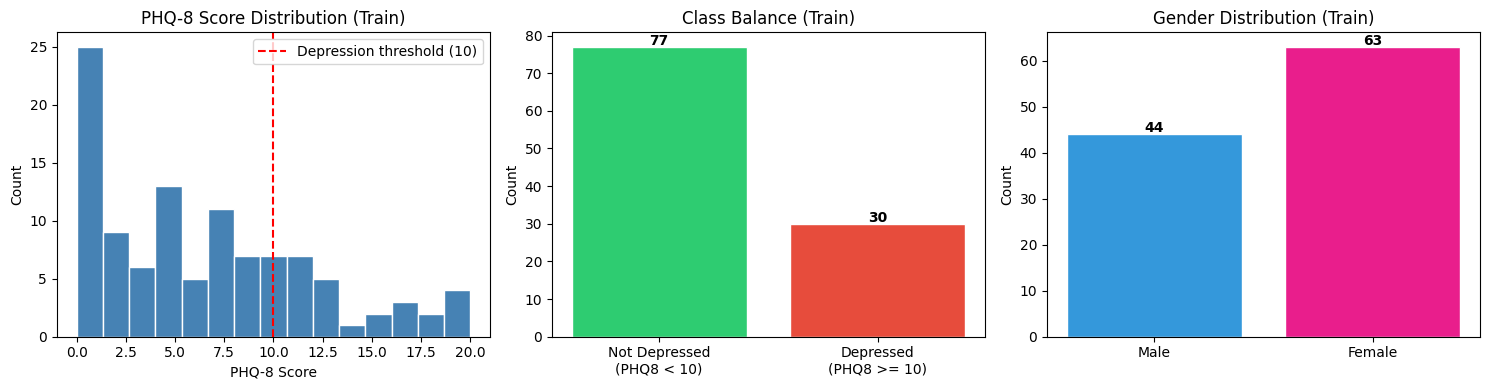

✅ Plot saved


In [ ]:
import matplotlib.pyplot as plt

# Add remounting of Google Drive as a potential fix for intermittent connection issues
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# PHQ8 score distribution
axes[0].hist(train_df['PHQ8_Score'], bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(x=10, color='red', linestyle='--', label='Depression threshold (10)')
axes[0].set_title('PHQ-8 Score Distribution (Train)')
axes[0].set_xlabel('PHQ-8 Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Class balance
labels = ['Not Depressed\n(PHQ8 < 10)', 'Depressed\n(PHQ8 >= 10)']
counts = [(train_df['PHQ8_Binary']==0).sum(), train_df['PHQ8_Binary'].sum()]
colors = ['#2ecc71', '#e74c3c']
axes[1].bar(labels, counts, color=colors, edgecolor='white')
axes[1].set_title('Class Balance (Train)')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Gender distribution
genders = ['Male', 'Female']
gcounts = [(train_df['Gender']==0).sum(), (train_df['Gender']==1).sum()]
axes[2].bar(genders, gcounts, color=['#3498db', '#e91e8c'], edgecolor='white')
axes[2].set_title('Gender Distribution (Train)')
axes[2].set_ylabel('Count')
for i, v in enumerate(gcounts):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FEATURES_PATH}/data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved")

## Section 4 — Unzip Session Folders

This unzips each participant's zip file. It only unzips files that haven't been extracted yet,
so we can safely re-run this cell without duplicating work.

⚠️ **Note:** Sessions 342, 394, 398, 460 are excluded by the dataset creators for technical reasons.


In [ ]:
# Sessions excluded by the dataset creators
EXCLUDED_SESSIONS = {342, 394, 398, 460}

def get_all_participant_ids():
    """Get all participant IDs from train + dev + test splits"""
    train_ids = set(train_df['Participant_ID'].tolist())
    dev_ids   = set(dev_df['Participant_ID'].tolist())
    test_ids  = set(test_df['participant_ID'].tolist())
    all_ids   = train_ids | dev_ids | test_ids
    return sorted(all_ids - EXCLUDED_SESSIONS)

all_ids = get_all_participant_ids()
print(f"Total participant IDs across all splits: {len(all_ids)}")
print(f"First 10 IDs: {all_ids[:10]}")


Total participant IDs across all splits: 189
First 10 IDs: [300, 301, 302, 303, 304, 305, 306, 307, 308, 309]


In [ ]:
def unzip_session(participant_id, drive_path, extract_path):
    """Unzip a single session folder if not already extracted"""
    zip_name = f"{participant_id}_P.zip"
    zip_path = os.path.join(drive_path, zip_name)
    out_path = os.path.join(extract_path, f"{participant_id}_P")

    if os.path.exists(out_path):
        return "already_extracted"

    if not os.path.exists(zip_path):
        return "zip_not_found"

    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    return "extracted"

# Unzip all sessions
results = {"extracted": 0, "already_extracted": 0, "zip_not_found": 0}
for pid in tqdm(all_ids, desc="Unzipping sessions"):
    result = unzip_session(pid, DRIVE_PATH, EXTRACT_PATH)
    results[result] += 1

print(f"\n✅ Newly extracted:    {results['extracted']}")
print(f"✅ Already extracted:  {results['already_extracted']}")
print(f"⚠️ ZIP not found:     {results['zip_not_found']}")


Unzipping sessions: 100%|██████████| 189/189 [2:09:03<00:00, 40.97s/it]


✅ Newly extracted:    189
✅ Already extracted:  0
⚠️ ZIP not found:     0


## Section 5 — Parse Transcripts & Extract Participant-Only Audio

The audio files contain BOTH the participant AND the virtual interviewer Ellie.
We use the transcript timestamps to extract only the participant's speech segments.

**Transcript file format (tab-separated):**
```
start_time   stop_time   speaker   value
0.00         1.50        Ellie     How are you feeling today?
2.10         5.30        Participant  I've been feeling pretty tired lately
```


In [ ]:
def parse_transcript(participant_id, extract_path):
    """
    Parse transcript CSV and return participant-only speech segments
    Returns list of (start_time, end_time) tuples in seconds
    """
    transcript_path = os.path.join(extract_path, f"{participant_id}_TRANSCRIPT.csv")

    if not os.path.exists(transcript_path):
        transcript_path = os.path.join(extract_path, f"{participant_id}_P",
                                       f"{participant_id}_TRANSCRIPT.csv")

    if not os.path.exists(transcript_path):
        return []

    try:
        df = pd.read_csv(transcript_path, sep='\t', header=0,
                         names=['start_time', 'stop_time', 'speaker', 'value'])

        # Keep only participant rows (not Ellie)
        participant_rows = df[
            df['speaker'].str.strip().str.lower().isin(['participant', 'p'])
        ]

        segments = []
        for _, row in participant_rows.iterrows():
            try:
                start = float(row['start_time'])
                end   = float(row['stop_time'])
                # Only keep segments longer than 0.5 seconds
                if end - start > 0.5:
                    segments.append((start, end))
            except:
                continue

        return segments

    except Exception as e:
        print(f"  Error parsing transcript for {participant_id}: {e}")
        return []

# Test on one participant
test_pid = train_df['Participant_ID'].iloc[0]
segments = parse_transcript(test_pid, EXTRACT_PATH)
print(f"Participant {test_pid}: {len(segments)} speech segments found")
if segments:
    total_duration = sum(e - s for s, e in segments)
    print(f"Total participant speech duration: {total_duration:.1f} seconds")
    print(f"First 5 segments: {segments[:5]}")


Participant 303: 102 speech segments found
Total participant speech duration: 642.5 seconds
First 5 segments: [(50.686, 51.836), (56.586, 57.996), (59.066, 59.756), (63.396, 67.696), (69.416, 72.266)]


In [ ]:
def extract_participant_audio(participant_id, extract_path, output_path):
    """
    Extract and concatenate participant-only speech from audio file
    Returns path to saved audio file, or None if failed
    """

    output_file  = os.path.join(output_path, f"{participant_id}_participant.wav")

    if os.path.exists(output_file):
        return output_file

    # Try flat structure first
    audio_path = os.path.join(extract_path, f"{participant_id}_AUDIO.wav")

    # Also try subfolder structure as fallback
    if not os.path.exists(audio_path):
        audio_path = os.path.join(extract_path, f"{participant_id}_P",
                                  f"{participant_id}_AUDIO.wav")

    if not os.path.exists(audio_path):
        print(f"  ⚠️ Audio not found for {participant_id}")
        return None

    # Get transcript segments
    segments = parse_transcript(participant_id, extract_path)

    if not segments:
        # If no transcript, use full audio
        import shutil
        shutil.copy(audio_path, output_file)
        return output_file

    # Load full audio
    audio, sr = librosa.load(audio_path, sr=16000)

    # Concatenate only participant segments
    participant_chunks = []
    for start, end in segments:
        start_sample = int(start * sr)
        end_sample   = int(end * sr)
        end_sample   = min(end_sample, len(audio))
        if start_sample < len(audio) and end_sample > start_sample:
            participant_chunks.append(audio[start_sample:end_sample])

    if not participant_chunks:
        return None

    # Concatenate all chunks
    participant_audio = np.concatenate(participant_chunks)

    # Save
    sf.write(output_file, participant_audio, sr)
    return output_file

# Test on one participant
output = extract_participant_audio(test_pid, EXTRACT_PATH,
                                   f'{FEATURES_PATH}/audio_segments')
if output:
    audio, sr = librosa.load(output, sr=16000)
    print(f"✅ Participant {test_pid} audio saved")
    print(f"   Duration: {len(audio)/sr:.1f} seconds")
    print(f"   Sample rate: {sr} Hz")
else:
    print(f"⚠️ Could not extract audio for participant {test_pid}")


✅ Participant 303 audio saved
   Duration: 642.5 seconds
   Sample rate: 16000 Hz


## Section 6 — Extract eGeMAPS Features (System 1)

eGeMAPS (extended Geneva Minimalistic Acoustic Parameter Set) extracts 88 acoustic features
including pitch, energy, speaking rate, MFCCs and more. This is the traditional feature approach.


In [ ]:
# Initialize openSMILE with eGeMAPS feature set
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals,
)

print(f"✅ openSMILE initialized")
print(f"Number of eGeMAPS features: {len(smile.feature_names)}")
print(f"First 10 features: {smile.feature_names[:10]}")


✅ openSMILE initialized
Number of eGeMAPS features: 88
First 10 features: ['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0', 'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2', 'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope', 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope', 'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope']


In [ ]:
def extract_egemaps(participant_id, audio_segments_path, features_path):
    """Extract eGeMAPS features for one participant"""
    audio_file   = os.path.join(audio_segments_path, f"{participant_id}_participant.wav")
    feature_file = os.path.join(features_path, 'egemaps', f"{participant_id}_egemaps.npy")

    if os.path.exists(feature_file):
        return np.load(feature_file)

    if not os.path.exists(audio_file):
        return None

    try:
        features = smile.process_file(audio_file)
        feature_vector = features.values.flatten()
        np.save(feature_file, feature_vector)
        return feature_vector
    except Exception as e:
        print(f"  Error extracting eGeMAPS for {participant_id}: {e}")
        return None

# Test on one participant
feats = extract_egemaps(test_pid,
                        f'{FEATURES_PATH}/audio_segments',
                        FEATURES_PATH)
if feats is not None:
    print(f"✅ eGeMAPS features for participant {test_pid}")
    print(f"   Feature vector shape: {feats.shape}")
    print(f"   Mean value: {feats.mean():.4f}")
else:
    print("⚠️ Feature extraction failed — check audio file exists")


✅ eGeMAPS features for participant 303
   Feature vector shape: (88,)
   Mean value: 106.6504


In [ ]:
def extract_all_egemaps(participant_ids, extract_path, features_path):
    """Extract eGeMAPS for all participants"""
    audio_path = f'{features_path}/audio_segments'

    # First extract all participant audio files
    print("Step 1: Extracting participant-only audio...")
    for pid in tqdm(participant_ids, desc="Extracting audio"):
        extract_participant_audio(pid, extract_path, audio_path)

    # Then extract eGeMAPS features
    print("\nStep 2: Extracting eGeMAPS features...")
    results = {}
    failed  = []

    for pid in tqdm(participant_ids, desc="Extracting eGeMAPS"):
        feats = extract_egemaps(pid, audio_path, features_path)
        if feats is not None:
            results[pid] = feats
        else:
            failed.append(pid)

    print(f"\n✅ eGeMAPS extracted for {len(results)} participants")
    print(f"⚠️ Failed: {len(failed)} participants {failed[:5] if failed else ''}")
    return results

# Get IDs for train + dev sets (these have labels)
labeled_ids = sorted(
    set(train_df['Participant_ID'].tolist()) |
    set(dev_df['Participant_ID'].tolist())
)
print(f"Extracting features for {len(labeled_ids)} labeled participants...")

egemaps_features = extract_all_egemaps(labeled_ids, EXTRACT_PATH, FEATURES_PATH)


Extracting features for 142 labeled participants...
Step 1: Extracting participant-only audio...


Extracting audio: 100%|██████████| 142/142 [04:05<00:00,  1.73s/it]



Step 2: Extracting eGeMAPS features...


Extracting eGeMAPS: 100%|██████████| 142/142 [33:45<00:00, 14.27s/it]


✅ eGeMAPS extracted for 142 participants
⚠️ Failed: 0 participants 


## Section 7 — Extract Wav2Vec 2.0 Embeddings (System 2)

Wav2Vec 2.0 is a pretrained transformer model from Facebook AI trained on 960 hours of speech.
It extracts rich contextual embeddings (768-dimensional vectors) from raw audio.


In [ ]:
# Load pretrained Wav2Vec 2.0 model
print("Loading Wav2Vec 2.0 model (this may take a minute)...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
wav2vec_model = wav2vec_model.to(device)
wav2vec_model.eval()

print("✅ Wav2Vec 2.0 loaded successfully")
print(f"Model parameters: {sum(p.numel() for p in wav2vec_model.parameters()):,}")


Loading Wav2Vec 2.0 model (this may take a minute)...
Using device: cuda


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Wav2Vec 2.0 loaded successfully
Model parameters: 94,371,712


In [ ]:
def extract_wav2vec(participant_id, audio_segments_path, features_path,
                    processor, model, device, max_duration=60):
    """
    Extract Wav2Vec 2.0 embeddings for one participant.
    Uses mean pooling over time to get a fixed-size vector.
    max_duration: limit audio to first N seconds to avoid memory issues
    """
    audio_file   = os.path.join(audio_segments_path, f"{participant_id}_participant.wav")
    feature_file = os.path.join(features_path, 'wav2vec', f"{participant_id}_wav2vec.npy")

    if os.path.exists(feature_file):
        return np.load(feature_file)

    if not os.path.exists(audio_file):
        return None

    try:
        # Load audio
        audio, sr = librosa.load(audio_file, sr=16000)

        # Limit duration to avoid GPU memory issues
        max_samples = max_duration * 16000
        if len(audio) > max_samples:
            audio = audio[:max_samples]

        # Process through Wav2Vec 2.0
        inputs = processor(audio, sampling_rate=16000,
                           return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = wav2vec_model(**inputs)

        # Mean pooling over time dimension → fixed 768-dim vector
        embeddings = outputs.last_hidden_state.mean(dim=1)
        feature_vector = embeddings.cpu().numpy().flatten()

        np.save(feature_file, feature_vector)
        return feature_vector

    except Exception as e:
        print(f"  Error extracting Wav2Vec for {participant_id}: {e}")
        return None

# Test on one participant
emb = extract_wav2vec(test_pid,
                      f'{FEATURES_PATH}/audio_segments',
                      FEATURES_PATH,
                      processor, wav2vec_model, device)
if emb is not None:
    print(f"✅ Wav2Vec 2.0 embeddings for participant {test_pid}")
    print(f"   Embedding shape: {emb.shape}")
    print(f"   Mean value: {emb.mean():.4f}")
else:
    print("⚠️ Embedding extraction failed")


✅ Wav2Vec 2.0 embeddings for participant 303
   Embedding shape: (768,)
   Mean value: -0.0011


In [ ]:
def extract_all_wav2vec(participant_ids, features_path, processor, model, device):
    """Extract Wav2Vec 2.0 embeddings for all participants"""
    audio_path = f'{features_path}/audio_segments'
    results = {}
    failed  = []

    for pid in tqdm(participant_ids, desc="Extracting Wav2Vec embeddings"):
        emb = extract_wav2vec(pid, audio_path, features_path,
                              processor, model, device)
        if emb is not None:
            results[pid] = emb
        else:
            failed.append(pid)

    print(f"\n✅ Wav2Vec extracted for {len(results)} participants")
    print(f"⚠️ Failed: {len(failed)} participants")
    return results

wav2vec_features = extract_all_wav2vec(
    labeled_ids, FEATURES_PATH, processor, wav2vec_model, device
)


Extracting Wav2Vec embeddings: 100%|██████████| 142/142 [01:02<00:00,  2.26it/s]


✅ Wav2Vec extracted for 142 participants
⚠️ Failed: 0 participants


## Section 8 — Build Feature Matrices for All 3 Systems

In [ ]:
def build_feature_matrix(participant_ids, egemaps_dict, wav2vec_dict, labels_df):
    """
    Build feature matrices for System 1, 2, and 3
    Returns X1 (eGeMAPS), X2 (Wav2Vec), X3 (fusion), y_reg (PHQ8), y_clf (binary)
    """
    X1, X2, X3 = [], [], []
    y_reg, y_clf = [], []
    valid_ids = []

    for pid in participant_ids:
        # Get label
        row = labels_df[labels_df['Participant_ID'] == pid]
        if len(row) == 0:
            continue

        score  = row['PHQ8_Score'].values[0]
        binary = row['PHQ8_Binary'].values[0]

        # Get features
        e = egemaps_dict.get(pid)
        w = wav2vec_dict.get(pid)

        if e is None or w is None:
            continue

        X1.append(e)
        X2.append(w)
        X3.append(np.concatenate([e, w]))   # Fusion = eGeMAPS + Wav2Vec
        y_reg.append(score)
        y_clf.append(binary)
        valid_ids.append(pid)

    return (np.array(X1), np.array(X2), np.array(X3),
            np.array(y_reg), np.array(y_clf), valid_ids)

# Build train matrices
train_ids = train_df['Participant_ID'].tolist()
X1_train, X2_train, X3_train, y_reg_train, y_clf_train, train_valid =     build_feature_matrix(train_ids, egemaps_features, wav2vec_features, train_df)

# Build dev matrices
dev_ids = dev_df['Participant_ID'].tolist()
X1_dev, X2_dev, X3_dev, y_reg_dev, y_clf_dev, dev_valid =     build_feature_matrix(dev_ids, egemaps_features, wav2vec_features, dev_df)

print("=== FEATURE MATRIX SHAPES ===")
print(f"Train — System 1 (eGeMAPS):  {X1_train.shape}")
print(f"Train — System 2 (Wav2Vec):  {X2_train.shape}")
print(f"Train — System 3 (Fusion):   {X3_train.shape}")
print(f"Train labels (regression):   {y_reg_train.shape}")
print(f"Train labels (binary):       {y_clf_train.shape}")
print(f"\nDev — System 1: {X1_dev.shape}")
print(f"Dev — System 2: {X2_dev.shape}")
print(f"Dev — System 3: {X3_dev.shape}")


=== FEATURE MATRIX SHAPES ===
Train — System 1 (eGeMAPS):  (107, 88)
Train — System 2 (Wav2Vec):  (107, 768)
Train — System 3 (Fusion):   (107, 856)
Train labels (regression):   (107,)
Train labels (binary):       (107,)

Dev — System 1: (35, 88)
Dev — System 2: (35, 768)
Dev — System 3: (35, 856)


In [ ]:
print("=== DIAGNOSTIC ===")
print(f"eGeMAPS features extracted : {len(egemaps_features)}")
print(f"Wav2Vec features extracted : {len(wav2vec_features)}")
print(f"Train participants         : {len(train_df)}")
print(f"Dev participants           : {len(dev_df)}")
print()

# Check feature matrices
print(f"X1_train shape : {X1_train.shape if hasattr(X1_train, 'shape') else 'not built yet'}")
print(f"X2_train shape : {X2_train.shape if hasattr(X2_train, 'shape') else 'not built yet'}")
print(f"X3_train shape : {X3_train.shape if hasattr(X3_train, 'shape') else 'not built yet'}")
print()

# Check audio files
import os
audio_files = os.listdir(AUDIO_SEG_PATH) if os.path.exists(AUDIO_SEG_PATH) else []
print(f"Audio segment files saved  : {len(audio_files)}")

# Check feature files
ege_files = os.listdir(f'{FEATURES_PATH}/egemaps') if os.path.exists(f'{FEATURES_PATH}/egemaps') else []
w2v_files = os.listdir(f'{FEATURES_PATH}/wav2vec') if os.path.exists(f'{FEATURES_PATH}/wav2vec') else []
print(f"eGeMAPS .npy files saved   : {len(ege_files)}")
print(f"Wav2Vec .npy files saved   : {len(w2v_files)}")

=== DIAGNOSTIC ===
eGeMAPS features extracted : 142
Wav2Vec features extracted : 142
Train participants         : 107
Dev participants           : 35

X1_train shape : (107, 88)
X2_train shape : (107, 768)
X3_train shape : (107, 856)

Audio segment files saved  : 0
eGeMAPS .npy files saved   : 142
Wav2Vec .npy files saved   : 142


In [ ]:
# Scale features (important for SVM)
scaler1 = StandardScaler()
scaler2 = StandardScaler()
scaler3 = StandardScaler()

X1_train_sc = scaler1.fit_transform(X1_train)
X2_train_sc = scaler2.fit_transform(X2_train)
X3_train_sc = scaler3.fit_transform(X3_train)

X1_dev_sc = scaler1.transform(X1_dev)
X2_dev_sc = scaler2.transform(X2_dev)
X3_dev_sc = scaler3.transform(X3_dev)

print("✅ Features scaled using StandardScaler")


✅ Features scaled using StandardScaler


## Section 9 — Train & Evaluate All Models

We train all models on the **train split** and evaluate on the **dev split**.

**Regression task** → predict PHQ-8 score (0–24), evaluated with RMSE and MAE  
**Classification task** → predict depressed/not (binary), evaluated with F1 and Accuracy


In [ ]:
def evaluate_regression(model, X_train, X_dev, y_train, y_dev, name):
    """Train and evaluate a regression model"""
    model.fit(X_train, y_train)
    preds = model.predict(X_dev)
    rmse  = np.sqrt(mean_squared_error(y_dev, preds))
    mae   = mean_absolute_error(y_dev, preds)
    print(f"  {name:35s} RMSE: {rmse:.3f}  MAE: {mae:.3f}")
    return {"model": name, "RMSE": round(rmse,3), "MAE": round(mae,3), "preds": preds}

def evaluate_classification(model, X_train, X_dev, y_train, y_dev, name):
    """Train and evaluate a classification model"""
    model.fit(X_train, y_train)
    preds = model.predict(X_dev)
    f1    = f1_score(y_dev, preds, average='weighted', zero_division=0)
    acc   = accuracy_score(y_dev, preds)
    print(f"  {name:35s} F1: {f1:.3f}  Acc: {acc:.3f}")
    return {"model": name, "F1": round(f1,3), "Accuracy": round(acc,3), "preds": preds}


In [ ]:
print("=" * 65)
print("REGRESSION RESULTS (predicting PHQ-8 score)")
print("=" * 65)

reg_results = []

print("\n-- System 1: eGeMAPS features --")
reg_results.append(evaluate_regression(SVR(kernel='rbf', C=1.0),
    X1_train_sc, X1_dev_sc, y_reg_train, y_reg_dev, "SVR (eGeMAPS)"))
reg_results.append(evaluate_regression(RandomForestRegressor(n_estimators=100, random_state=42),
    X1_train, X1_dev, y_reg_train, y_reg_dev, "Random Forest (eGeMAPS)"))
reg_results.append(evaluate_regression(XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    X1_train, X1_dev, y_reg_train, y_reg_dev, "XGBoost (eGeMAPS)"))

print("\n-- System 2: Wav2Vec 2.0 embeddings --")
reg_results.append(evaluate_regression(SVR(kernel='rbf', C=1.0),
    X2_train_sc, X2_dev_sc, y_reg_train, y_reg_dev, "SVR (Wav2Vec)"))
reg_results.append(evaluate_regression(LinearRegression(),
    X2_train_sc, X2_dev_sc, y_reg_train, y_reg_dev, "Linear Regression (Wav2Vec)"))

print("\n-- System 3: Fusion (eGeMAPS + Wav2Vec) --")
reg_results.append(evaluate_regression(SVR(kernel='rbf', C=1.0),
    X3_train_sc, X3_dev_sc, y_reg_train, y_reg_dev, "SVR (Fusion)"))
reg_results.append(evaluate_regression(RandomForestRegressor(n_estimators=100, random_state=42),
    X3_train, X3_dev, y_reg_train, y_reg_dev, "Random Forest (Fusion)"))
reg_results.append(evaluate_regression(XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    X3_train, X3_dev, y_reg_train, y_reg_dev, "XGBoost (Fusion)"))


REGRESSION RESULTS (predicting PHQ-8 score)

-- System 1: eGeMAPS features --
  SVR (eGeMAPS)                       RMSE: 6.677  MAE: 5.452
  Random Forest (eGeMAPS)             RMSE: 6.754  MAE: 5.624
  XGBoost (eGeMAPS)                   RMSE: 7.531  MAE: 6.013

-- System 2: Wav2Vec 2.0 embeddings --
  SVR (Wav2Vec)                       RMSE: 6.733  MAE: 5.448
  Linear Regression (Wav2Vec)         RMSE: 7.739  MAE: 5.621

-- System 3: Fusion (eGeMAPS + Wav2Vec) --
  SVR (Fusion)                        RMSE: 6.707  MAE: 5.439
  Random Forest (Fusion)              RMSE: 6.788  MAE: 5.674
  XGBoost (Fusion)                    RMSE: 7.372  MAE: 6.122


In [ ]:
print("=" * 65)
print("CLASSIFICATION RESULTS (depressed vs not depressed)")
print("=" * 65)

clf_results = []

# Use class_weight='balanced' to handle class imbalance
print("\n-- System 1: eGeMAPS features --")
clf_results.append(evaluate_classification(
    SVC(kernel='rbf', C=1.0, class_weight='balanced'),
    X1_train_sc, X1_dev_sc, y_clf_train, y_clf_dev, "SVC (eGeMAPS)"))
clf_results.append(evaluate_classification(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    X1_train, X1_dev, y_clf_train, y_clf_dev, "Random Forest (eGeMAPS)"))
clf_results.append(evaluate_classification(
    XGBClassifier(n_estimators=100, random_state=42,
                  scale_pos_weight=len(y_clf_train[y_clf_train==0])/len(y_clf_train[y_clf_train==1]),
                  verbosity=0),
    X1_train, X1_dev, y_clf_train, y_clf_dev, "XGBoost (eGeMAPS)"))

print("\n-- System 2: Wav2Vec 2.0 embeddings --")
clf_results.append(evaluate_classification(
    SVC(kernel='rbf', C=1.0, class_weight='balanced'),
    X2_train_sc, X2_dev_sc, y_clf_train, y_clf_dev, "SVC (Wav2Vec)"))
clf_results.append(evaluate_classification(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    X2_train_sc, X2_dev_sc, y_clf_train, y_clf_dev, "Logistic Regression (Wav2Vec)"))

print("\n-- System 3: Fusion (eGeMAPS + Wav2Vec) --")
clf_results.append(evaluate_classification(
    SVC(kernel='rbf', C=1.0, class_weight='balanced'),
    X3_train_sc, X3_dev_sc, y_clf_train, y_clf_dev, "SVC (Fusion)"))
clf_results.append(evaluate_classification(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    X3_train, X3_dev, y_clf_train, y_clf_dev, "Random Forest (Fusion)"))
clf_results.append(evaluate_classification(
    XGBClassifier(n_estimators=100, random_state=42,
                  scale_pos_weight=len(y_clf_train[y_clf_train==0])/len(y_clf_train[y_clf_train==1]),
                  verbosity=0),
    X3_train, X3_dev, y_clf_train, y_clf_dev, "XGBoost (Fusion)"))


CLASSIFICATION RESULTS (depressed vs not depressed)

-- System 1: eGeMAPS features --
  SVC (eGeMAPS)                       F1: 0.598  Acc: 0.629
  Random Forest (eGeMAPS)             F1: 0.521  Acc: 0.657
  XGBoost (eGeMAPS)                   F1: 0.554  Acc: 0.571

-- System 2: Wav2Vec 2.0 embeddings --
  SVC (Wav2Vec)                       F1: 0.575  Acc: 0.571
  Logistic Regression (Wav2Vec)       F1: 0.624  Acc: 0.629

-- System 3: Fusion (eGeMAPS + Wav2Vec) --
  SVC (Fusion)                        F1: 0.543  Acc: 0.543
  Random Forest (Fusion)              F1: 0.521  Acc: 0.657
  XGBoost (Fusion)                    F1: 0.617  Acc: 0.686


## Section 10 — Results Summary & Visualisation

In [ ]:
# Regression results table
reg_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'preds'} for r in reg_results])
reg_df = reg_df.sort_values('RMSE')
print("=== REGRESSION RESULTS (sorted by RMSE — lower is better) ===")
print(reg_df.to_string(index=False))

print("\n=== CLASSIFICATION RESULTS (sorted by F1 — higher is better) ===")
clf_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'preds'} for r in clf_results])
clf_df = clf_df.sort_values('F1', ascending=False)
print(clf_df.to_string(index=False))


=== REGRESSION RESULTS (sorted by RMSE — lower is better) ===
                      model  RMSE   MAE
              SVR (eGeMAPS) 6.677 5.452
               SVR (Fusion) 6.707 5.439
              SVR (Wav2Vec) 6.733 5.448
    Random Forest (eGeMAPS) 6.754 5.624
     Random Forest (Fusion) 6.788 5.674
           XGBoost (Fusion) 7.372 6.122
          XGBoost (eGeMAPS) 7.531 6.013
Linear Regression (Wav2Vec) 7.739 5.621

=== CLASSIFICATION RESULTS (sorted by F1 — higher is better) ===
                        model    F1  Accuracy
Logistic Regression (Wav2Vec) 0.624     0.629
             XGBoost (Fusion) 0.617     0.686
                SVC (eGeMAPS) 0.598     0.629
                SVC (Wav2Vec) 0.575     0.571
            XGBoost (eGeMAPS) 0.554     0.571
                 SVC (Fusion) 0.543     0.543
      Random Forest (eGeMAPS) 0.521     0.657
       Random Forest (Fusion) 0.521     0.657


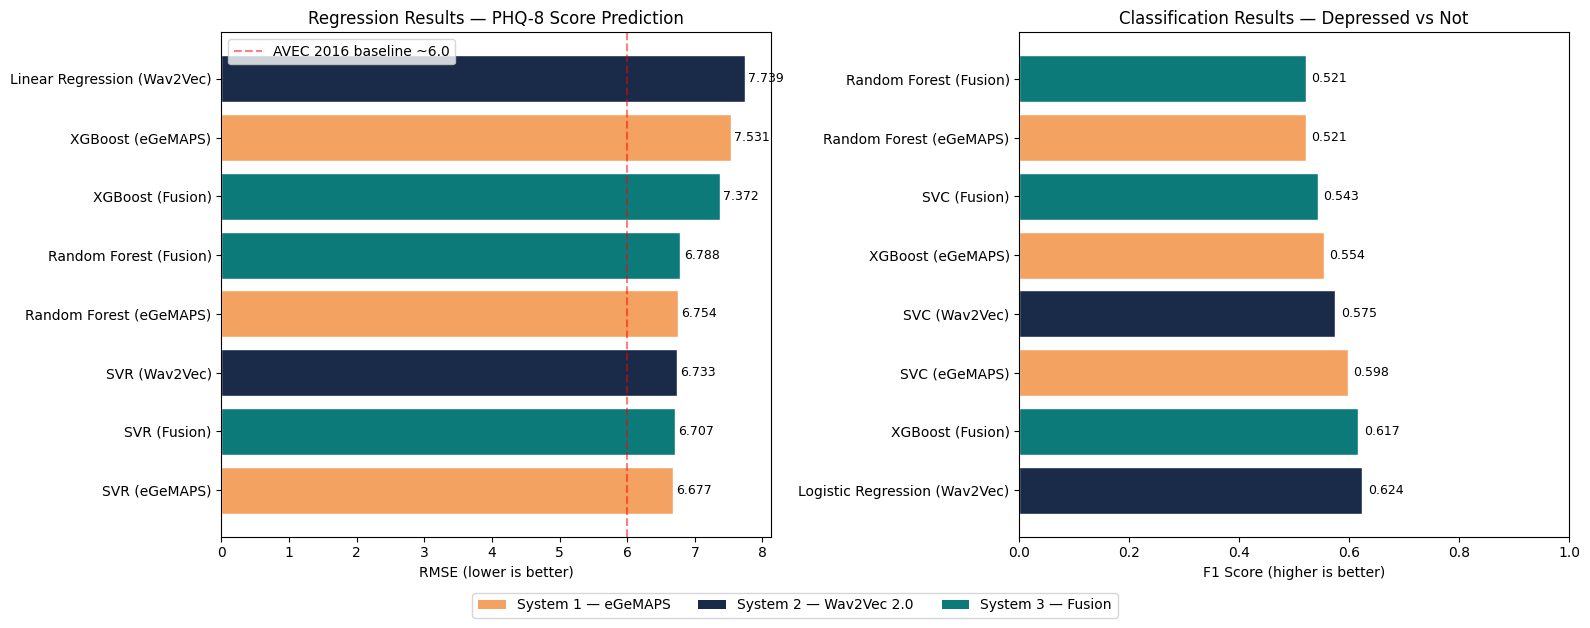

✅ Results plot saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by system
def get_color(name):
    if 'Fusion' in name:   return '#0D7A7A'
    if 'Wav2Vec' in name:  return '#1A2B4A'
    return '#F4A261'

# Regression plot
reg_plot = reg_df.copy()
colors = [get_color(n) for n in reg_plot['model']]
bars = axes[0].barh(reg_plot['model'], reg_plot['RMSE'], color=colors, edgecolor='white')
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('Regression Results — PHQ-8 Score Prediction')
axes[0].axvline(x=6.0, color='red', linestyle='--', alpha=0.5, label='AVEC 2016 baseline ~6.0')
axes[0].legend()
for bar, val in zip(bars, reg_plot['RMSE']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Classification plot
clf_plot = clf_df.copy()
colors2 = [get_color(n) for n in clf_plot['model']]
bars2 = axes[1].barh(clf_plot['model'], clf_plot['F1'], color=colors2, edgecolor='white')
axes[1].set_xlabel('F1 Score (higher is better)')
axes[1].set_title('Classification Results — Depressed vs Not')
axes[1].set_xlim(0, 1)
for bar, val in zip(bars2, clf_plot['F1']):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F4A261', label='System 1 — eGeMAPS'),
    Patch(facecolor='#1A2B4A', label='System 2 — Wav2Vec 2.0'),
    Patch(facecolor='#0D7A7A', label='System 3 — Fusion'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.05), frameon=True)

plt.tight_layout()
plt.savefig(f'{FEATURES_PATH}/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Results plot saved")


## Section 11 — Save All Features & Results to Drive

In [ ]:
import shutil

# Save results CSVs
reg_df.to_csv(f'{DRIVE_PATH}/regression_results.csv', index=False)
clf_df.to_csv(f'{DRIVE_PATH}/classification_results.csv', index=False)

# Save feature matrices
np.save(f'{DRIVE_PATH}/X1_train_egemaps.npy', X1_train)
np.save(f'{DRIVE_PATH}/X2_train_wav2vec.npy', X2_train)
np.save(f'{DRIVE_PATH}/X3_train_fusion.npy',  X3_train)
np.save(f'{DRIVE_PATH}/X1_dev_egemaps.npy',   X1_dev)
np.save(f'{DRIVE_PATH}/X2_dev_wav2vec.npy',   X2_dev)
np.save(f'{DRIVE_PATH}/X3_dev_fusion.npy',    X3_dev)
np.save(f'{DRIVE_PATH}/y_reg_train.npy',      y_reg_train)
np.save(f'{DRIVE_PATH}/y_clf_train.npy',      y_clf_train)
np.save(f'{DRIVE_PATH}/y_reg_dev.npy',        y_reg_dev)
np.save(f'{DRIVE_PATH}/y_clf_dev.npy',        y_clf_dev)

# Copy plots to Drive
shutil.copy(f'{FEATURES_PATH}/results_comparison.png', f'{DRIVE_PATH}/results_comparison.png')
shutil.copy(f'{FEATURES_PATH}/data_exploration.png',   f'{DRIVE_PATH}/data_exploration.png')

print("✅ All results and features saved to Google Drive")
print(f"   Location: {DRIVE_PATH}")


✅ All results and features saved to Google Drive
   Location: /content/drive/MyDrive/Speech and audio understanding/DAIC-WOZ


---
## Section 12 — Setup: Install, Import & Reload Features

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── SET YOUR PATHS ─────────────────────────────────────────────────
DRIVE_PATH    = '/content/drive/MyDrive/Speech and audio understanding/DAIC-WOZ'
FEATURES_PATH = '/content/drive/MyDrive/Speech and audio understanding/features'
RESULTS_PATH  = '/content/drive/MyDrive/Speech and audio understanding/DAIC-WOZ/results'
NEXT_STEPS_PATH = '/content/drive/MyDrive/Speech and audio understanding/DAIC-WOZ/next_steps'
# ──────────────────────────────────────────────────────────────────

os.makedirs(NEXT_STEPS_PATH, exist_ok=True)
print("✅ Drive mounted and paths set")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted and paths set


In [ ]:
# Reload all feature matrices saved from main pipeline
X1_train = np.load(f'{DRIVE_PATH}/X1_train_egemaps.npy')
X2_train = np.load(f'{DRIVE_PATH}/X2_train_wav2vec.npy')
X3_train = np.load(f'{DRIVE_PATH}/X3_train_fusion.npy')
X1_dev   = np.load(f'{DRIVE_PATH}/X1_dev_egemaps.npy')
X2_dev   = np.load(f'{DRIVE_PATH}/X2_dev_wav2vec.npy')
X3_dev   = np.load(f'{DRIVE_PATH}/X3_dev_fusion.npy')
y_reg_train = np.load(f'{DRIVE_PATH}/y_reg_train.npy')
y_clf_train = np.load(f'{DRIVE_PATH}/y_clf_train.npy')
y_reg_dev   = np.load(f'{DRIVE_PATH}/y_reg_dev.npy')
y_clf_dev   = np.load(f'{DRIVE_PATH}/y_clf_dev.npy')

# Reload labels for gender
train_df = pd.read_csv(f'{DRIVE_PATH}/train_split_Depression_AVEC2017.csv')
dev_df   = pd.read_csv(f'{DRIVE_PATH}/dev_split_Depression_AVEC2017.csv')

# Scale features
sc1 = StandardScaler().fit(X1_train)
sc2 = StandardScaler().fit(X2_train)
sc3 = StandardScaler().fit(X3_train)
X1_train_s = sc1.transform(X1_train); X1_dev_s = sc1.transform(X1_dev)
X2_train_s = sc2.transform(X2_train); X2_dev_s = sc2.transform(X2_dev)
X3_train_s = sc3.transform(X3_train); X3_dev_s = sc3.transform(X3_dev)

# Class imbalance ratio for XGBoost
ratio = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

print(f"✅ All features reloaded")
print(f"   X1_train (eGeMAPS) : {X1_train.shape}")
print(f"   X2_train (Wav2Vec) : {X2_train.shape}")
print(f"   X3_train (Fusion)  : {X3_train.shape}")
print(f"   y_reg_train        : {y_reg_train.shape}")
print(f"   Class ratio        : {ratio:.1f}")


✅ All features reloaded
   X1_train (eGeMAPS) : (107, 88)
   X2_train (Wav2Vec) : (107, 768)
   X3_train (Fusion)  : (107, 856)
   y_reg_train        : (107,)
   Class ratio        : 2.6


In [ ]:
# Get eGeMAPS feature names from openSMILE
smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.eGeMAPSv02,
    feature_level=opensmile.FeatureLevel.Functionals)
feature_names = smile.feature_names
print(f"✅ eGeMAPS feature names loaded: {len(feature_names)} features")
print(f"   First 5: {feature_names[:5]}")


✅ eGeMAPS feature names loaded: 88 features
   First 5: ['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0']


Section 13 — Feature Importance Analysis
Which of the 88 eGeMAPS acoustic features predict depression best?

We use two complementary methods:

Random Forest Feature Importance — which features the model uses most to make decisions
Pearson Correlation — how strongly each feature correlates with PHQ-8 score (positive = higher score, negative = lower)
Why this matters for the paper: If the top features align with what clinical literature says should matter (pitch variability, pause duration, vocal energy), it validates our approach scientifically.

In [ ]:
# ── Train Random Forest on eGeMAPS ──────────────────────────────
print("Training Random Forest for feature importance...")
rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_reg.fit(X1_train, y_reg_train)

preds_rf = rf_reg.predict(X1_dev)
rmse_rf  = np.sqrt(mean_squared_error(y_reg_dev, preds_rf))
print(f"Random Forest RMSE on dev set: {rmse_rf:.3f}")

# Extract importances
importances = rf_reg.feature_importances_
top_n = 20
top_idx   = np.argsort(importances)[::-1][:top_n]
top_names = [feature_names[i] for i in top_idx]
top_vals  = importances[top_idx]

print(f"\nTop 10 most important features:")
for i, (name, val) in enumerate(zip(top_names[:10], top_vals[:10])):
    bar = '█' * int(val * 500)
    print(f"  {i+1:2d}. {name:50s} {val:.4f} {bar}")


Training Random Forest for feature importance...
Random Forest RMSE on dev set: 6.767

Top 10 most important features:
   1. F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope        0.0629 ███████████████████████████████
   2. spectralFlux_sma3_stddevNorm                       0.0465 ███████████████████████
   3. equivalentSoundLevel_dBp                           0.0426 █████████████████████
   4. slopeV500-1500_sma3nz_amean                        0.0304 ███████████████
   5. logRelF0-H1-H2_sma3nz_amean                        0.0298 ██████████████
   6. mfcc1_sma3_amean                                   0.0243 ████████████
   7. F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope      0.0233 ███████████
   8. slopeV0-500_sma3nz_amean                           0.0194 █████████
   9. mfcc3_sma3_stddevNorm                              0.0172 ████████
  10. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope       0.0158 ███████


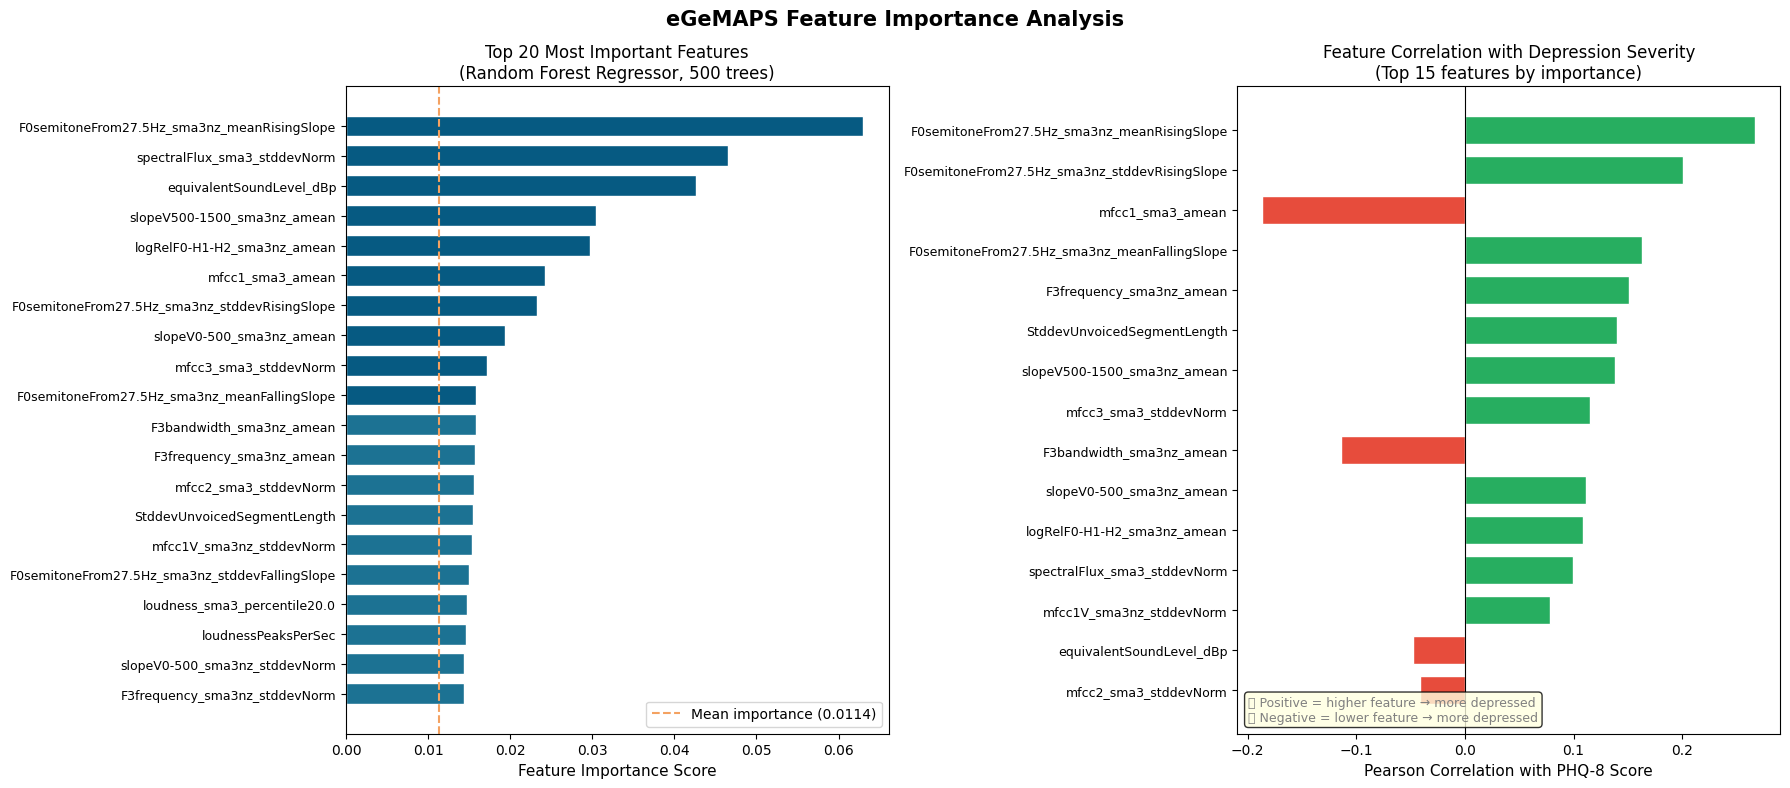

✅ Feature importance chart saved


In [ ]:
# ── Feature Importance Chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('eGeMAPS Feature Importance Analysis', fontsize=15, fontweight='bold')

# Chart 1 — Top 20 feature importances
colors = ['#065A82' if v > np.median(top_vals) else '#1C7293' for v in top_vals]
axes[0].barh(top_names[::-1], top_vals[::-1], color=colors[::-1], edgecolor='white', height=0.7)
axes[0].axvline(np.mean(importances), color='#F4A261', linestyle='--', linewidth=1.5,
                label=f'Mean importance ({np.mean(importances):.4f})')
axes[0].set_xlabel('Feature Importance Score', fontsize=11)
axes[0].set_title(f'Top {top_n} Most Important Features\n(Random Forest Regressor, 500 trees)', fontsize=12)
axes[0].legend()
axes[0].tick_params(axis='y', labelsize=9)

# Chart 2 — Pearson correlation of top features with PHQ-8
top10_idx = top_idx[:15]
correlations = []
for i in top10_idx:
    corr = np.corrcoef(X1_train[:, i], y_reg_train)[0, 1]
    correlations.append((feature_names[i], corr))
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

names_c = [c[0] for c in correlations]
vals_c  = [c[1] for c in correlations]
col_c   = ['#E74C3C' if v < 0 else '#27AE60' for v in vals_c]

axes[1].barh(names_c[::-1], vals_c[::-1], color=col_c[::-1], edgecolor='white', height=0.7)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson Correlation with PHQ-8 Score', fontsize=11)
axes[1].set_title('Feature Correlation with Depression Severity\n(Top 15 features by importance)', fontsize=12)
axes[1].tick_params(axis='y', labelsize=9)

# Add annotation
axes[1].text(0.02, 0.02, '🟢 Positive = higher feature → more depressed\n🔴 Negative = lower feature → more depressed',
             transform=axes[1].transAxes, fontsize=9, color='gray',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{NEXT_STEPS_PATH}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved")


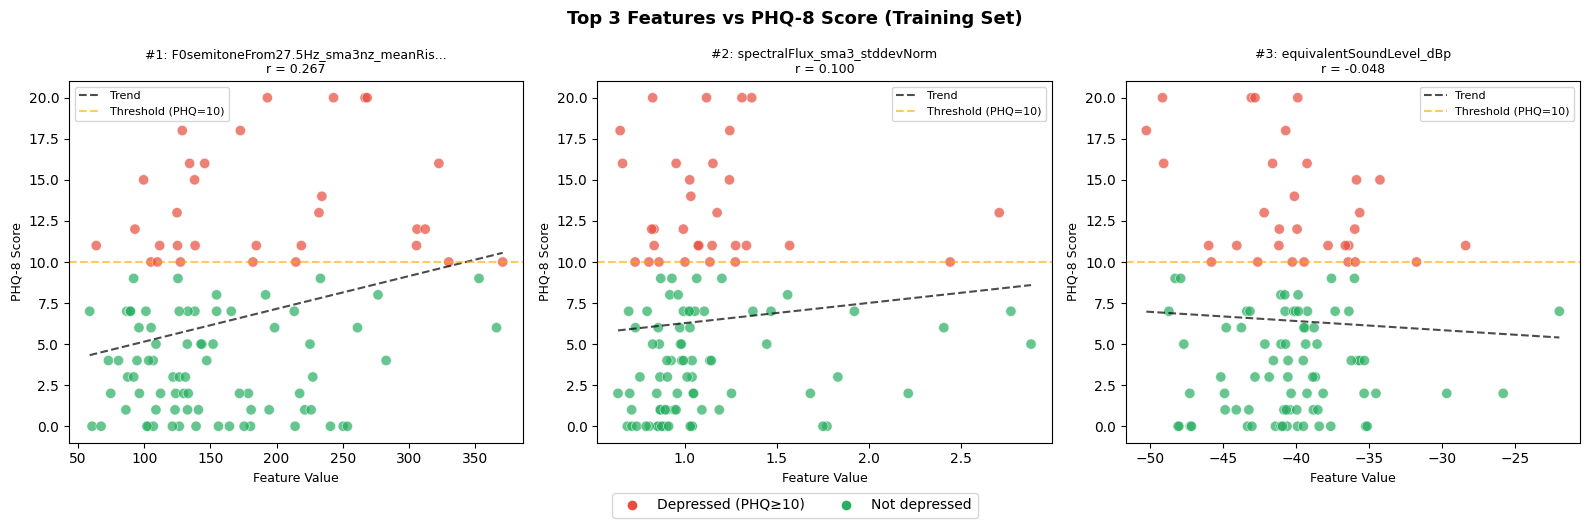

✅ Feature scatter plot saved


In [ ]:
# ── Feature scatter plots — top 3 vs PHQ-8 ─────────────────────
top3_idx = top_idx[:3]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top 3 Features vs PHQ-8 Score (Training Set)', fontsize=13, fontweight='bold')

for i, (ax, feat_idx) in enumerate(zip(axes, top3_idx)):
    feat_name = feature_names[feat_idx]
    feat_vals = X1_train[:, feat_idx]
    point_colors = ['#E74C3C' if y >= 10 else '#27AE60' for y in y_reg_train]

    ax.scatter(feat_vals, y_reg_train, c=point_colors, alpha=0.7,
               edgecolors='white', linewidth=0.5, s=55)

    # Trend line
    z = np.polyfit(feat_vals, y_reg_train, 1)
    p = np.poly1d(z)
    x_line = np.linspace(feat_vals.min(), feat_vals.max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, alpha=0.7, label='Trend')
    ax.axhline(y=10, color='orange', linestyle='--', alpha=0.6, label='Threshold (PHQ=10)')

    corr = np.corrcoef(feat_vals, y_reg_train)[0, 1]
    short_name = feat_name[:35] + '...' if len(feat_name) > 35 else feat_name
    ax.set_title(f'#{i+1}: {short_name}\nr = {corr:.3f}', fontsize=9)
    ax.set_xlabel('Feature Value', fontsize=9)
    ax.set_ylabel('PHQ-8 Score', fontsize=9)
    ax.legend(fontsize=8)

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#E74C3C', markersize=8, label='Depressed (PHQ≥10)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#27AE60', markersize=8, label='Not depressed'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout()
plt.savefig(f'{NEXT_STEPS_PATH}/feature_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature scatter plot saved")


In [ ]:
# ── Summary table of top features ───────────────────────────────
print("=" * 75)
print(f"{'Rank':<5} {'Feature Name':<52} {'Importance':>10} {'Corr w PHQ8':>12}")
print("=" * 75)
for rank, (idx, imp) in enumerate(zip(top_idx[:15], top_vals[:15])):
    name = feature_names[idx]
    corr = np.corrcoef(X1_train[:, idx], y_reg_train)[0, 1]
    direction = "↑ more depressed" if corr > 0 else "↓ less depressed"
    print(f"{rank+1:<5} {name:<52} {imp:>10.4f} {corr:>+12.3f}")
print()
print("Interpretation:")
print("  Importance > 0.02 = meaningfully used by Random Forest")
print("  Correlation sign shows direction of effect on PHQ-8 score")


Rank  Feature Name                                         Importance  Corr w PHQ8
1     F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope              0.0629       +0.267
2     spectralFlux_sma3_stddevNorm                             0.0465       +0.100
3     equivalentSoundLevel_dBp                                 0.0426       -0.048
4     slopeV500-1500_sma3nz_amean                              0.0304       +0.138
5     logRelF0-H1-H2_sma3nz_amean                              0.0298       +0.109
6     mfcc1_sma3_amean                                         0.0243       -0.187
7     F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope            0.0233       +0.201
8     slopeV0-500_sma3nz_amean                                 0.0194       +0.111
9     mfcc3_sma3_stddevNorm                                    0.0172       +0.115
10    F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope             0.0158       +0.163
11    F3bandwidth_sma3nz_amean                                 0.0158       -0.114
12  

---
## Section 14 — Hyperparameter Tuning
**Optimize the two best performing models from the main pipeline:**
- **SVR on eGeMAPS** (best regression: RMSE 6.677)
- **Logistic Regression on Wav2Vec** (best classification: F1 0.624)

**What is hyperparameter tuning?**
Models have settings (hyperparameters) that you choose before training — like how strict an SVM is, or how strongly it regularizes. GridSearchCV tries every combination of settings and finds the best one using cross-validation on the training set.

**What is cross-validation?**
Instead of a single train/dev split, it splits the training data into 5 folds, trains on 4 and evaluates on 1, repeating 5 times. This gives a more reliable estimate of model performance.


In [ ]:
# ── REGRESSION: Tune SVR on eGeMAPS ────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             f1_score, accuracy_score)
from sklearn.model_selection import GridSearchCV, cross_val_score
from xgboost import XGBRegressor, XGBClassifier
import opensmile

print("✅ All imports restored")
print("Tuning SVR on eGeMAPS features...")
print("This tests different C and gamma values — may take 2-3 minutes...")
print()

# Parameter grid
param_grid_svr = {
    'C':      [0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear'],
}

svr_base = SVR()
grid_svr = GridSearchCV(
    svr_base,
    param_grid_svr,
    cv=5,                          # 5-fold cross-validation
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,                     # use all CPU cores
    verbose=1
)
grid_svr.fit(X1_train_s, y_reg_train)

print(f"\n✅ SVR tuning complete")
print(f"   Best parameters : {grid_svr.best_params_}")
print(f"   Best CV RMSE    : {-grid_svr.best_score_:.3f}")

# Evaluate best model on dev set
best_svr = grid_svr.best_estimator_
preds_svr_tuned = best_svr.predict(X1_dev_s)
rmse_tuned = np.sqrt(mean_squared_error(y_reg_dev, preds_svr_tuned))
mae_tuned  = mean_absolute_error(y_reg_dev, preds_svr_tuned)

print(f"\n   Dev RMSE before tuning : 6.677")
print(f"   Dev RMSE after tuning  : {rmse_tuned:.3f}")
improvement_reg = 6.677 - rmse_tuned
if improvement_reg > 0:
    print(f"   ✅ Improvement: {improvement_reg:.3f} RMSE points")
else:
    print(f"   ⚠️  No improvement: {abs(improvement_reg):.3f} worse (may indicate overfitting)")


✅ All imports restored
Tuning SVR on eGeMAPS features...
This tests different C and gamma values — may take 2-3 minutes...

Fitting 5 folds for each of 60 candidates, totalling 300 fits

✅ SVR tuning complete
   Best parameters : {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
   Best CV RMSE    : 5.440

   Dev RMSE before tuning : 6.677
   Dev RMSE after tuning  : 7.340
   ⚠️  No improvement: 0.663 worse (may indicate overfitting)


In [ ]:
# ── CLASSIFICATION: Tune Logistic Regression on Wav2Vec ─────────
print("Tuning Logistic Regression on Wav2Vec features...")
print()

param_grid_lr = {
    'C':       [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver':  ['lbfgs', 'liblinear', 'saga'],
    'max_iter': [500, 1000, 2000],
}

lr_base = LogisticRegression(class_weight='balanced', random_state=42)
grid_lr = GridSearchCV(
    lr_base,
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_lr.fit(X2_train_s, y_clf_train)

print(f"\n✅ Logistic Regression tuning complete")
print(f"   Best parameters : {grid_lr.best_params_}")
print(f"   Best CV F1      : {grid_lr.best_score_:.3f}")

# Evaluate on dev set
best_lr = grid_lr.best_estimator_
preds_lr_tuned = best_lr.predict(X2_dev_s)
f1_tuned  = f1_score(y_clf_dev, preds_lr_tuned, average='weighted', zero_division=0)
acc_tuned = accuracy_score(y_clf_dev, preds_lr_tuned)

print(f"\n   Dev F1 before tuning : 0.624")
print(f"   Dev F1 after tuning  : {f1_tuned:.3f}")
improvement_clf = f1_tuned - 0.624
if improvement_clf > 0:
    print(f"   ✅ Improvement: +{improvement_clf:.3f} F1 points")
else:
    print(f"   ⚠️  No improvement: {abs(improvement_clf):.3f} worse")


Tuning Logistic Regression on Wav2Vec features...

Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Logistic Regression tuning complete
   Best parameters : {'C': 0.1, 'max_iter': 500, 'solver': 'lbfgs'}
   Best CV F1      : 0.646

   Dev F1 before tuning : 0.624
   Dev F1 after tuning  : 0.550
   ⚠️  No improvement: 0.074 worse


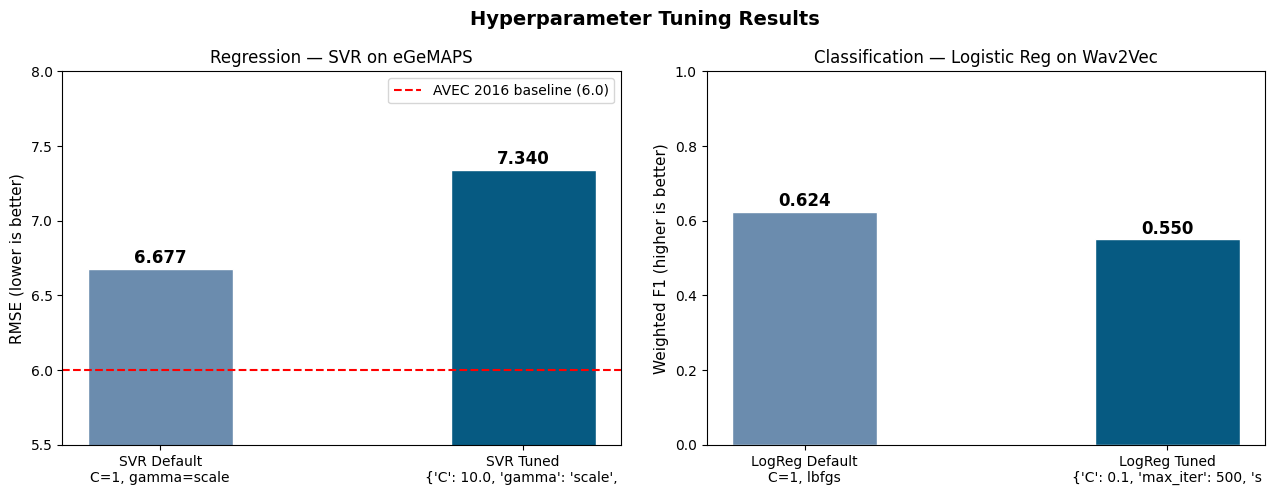

✅ Tuning comparison chart saved


In [ ]:
# ── Tuning results comparison chart ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Hyperparameter Tuning Results', fontsize=14, fontweight='bold')

# Regression comparison
default_label = 'SVR Default\nC=1, gamma=scale'
best_params_str = str(grid_svr.best_params_)
tuned_label = f'SVR Tuned\n{best_params_str[:30]}'

models_reg  = [default_label, tuned_label]
rmse_values = [6.677, rmse_tuned]
colors_reg  = ['#6B8CAE', '#065A82']

bars = axes[0].bar(models_reg, rmse_values, color=colors_reg, edgecolor='white', width=0.4)
axes[0].axhline(y=6.0, color='red', linestyle='--', linewidth=1.5, label='AVEC 2016 baseline (6.0)')
axes[0].set_ylabel('RMSE (lower is better)', fontsize=11)
axes[0].set_title('Regression — SVR on eGeMAPS', fontsize=12)
axes[0].set_ylim(5.5, 8.0)
axes[0].legend()
for bar, val in zip(bars, rmse_values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.04,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)

# Classification comparison
default_label_clf = 'LogReg Default\nC=1, lbfgs'
best_params_clf_str = str(grid_lr.best_params_)
tuned_label_clf = f'LogReg Tuned\n{best_params_clf_str[:30]}'

models_clf = [default_label_clf, tuned_label_clf]
f1_values  = [0.624, f1_tuned]
colors_clf = ['#6B8CAE', '#065A82']

bars2 = axes[1].bar(models_clf, f1_values, color=colors_clf, edgecolor='white', width=0.4)
axes[1].set_ylabel('Weighted F1 (higher is better)', fontsize=11)
axes[1].set_title('Classification — Logistic Reg on Wav2Vec', fontsize=12)
axes[1].set_ylim(0, 1.0)
for bar, val in zip(bars2, f1_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.015,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(f'{NEXT_STEPS_PATH}/hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Tuning comparison chart saved")

In [ ]:
# ── Full tuning results summary ──────────────────────────────────
print("=" * 55)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 55)
print()
print("REGRESSION — SVR on eGeMAPS:")
print(f"  Default   RMSE : 6.677  (C=1.0, gamma=scale, kernel=rbf)")
print(f"  Tuned     RMSE : {rmse_tuned:.3f}  {grid_svr.best_params_}")
print(f"  AVEC 2016 RMSE : 6.000  (published baseline)")
delta_reg = 6.677 - rmse_tuned
print(f"  Change         : {'+'  if delta_reg < 0 else '-'}{abs(delta_reg):.3f} ({'worse' if delta_reg < 0 else 'better'})")
print()
print("CLASSIFICATION — Logistic Regression on Wav2Vec:")
print(f"  Default   F1   : 0.624  (C=1.0, lbfgs)")
print(f"  Tuned     F1   : {f1_tuned:.3f}  {grid_lr.best_params_}")
delta_clf = f1_tuned - 0.624
print(f"  Change         : {'+' if delta_clf > 0 else ''}{delta_clf:.3f} ({'better' if delta_clf > 0 else 'worse'})")


HYPERPARAMETER TUNING SUMMARY

REGRESSION — SVR on eGeMAPS:
  Default   RMSE : 6.677  (C=1.0, gamma=scale, kernel=rbf)
  Tuned     RMSE : 7.340  {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
  AVEC 2016 RMSE : 6.000  (published baseline)
  Change         : +0.663 (worse)

CLASSIFICATION — Logistic Regression on Wav2Vec:
  Default   F1   : 0.624  (C=1.0, lbfgs)
  Tuned     F1   : 0.550  {'C': 0.1, 'max_iter': 500, 'solver': 'lbfgs'}
  Change         : -0.074 (worse)


Section 15 — Attention-Weighted Fusion (System 4)
The main pipeline used simple concatenation for fusion (System 3) — which did not consistently improve results.

Why simple concatenation failed: Concatenating 88 eGeMAPS features with 768 Wav2Vec features into 856 numbers gives all features equal weight. But the 768 Wav2Vec dimensions dominate just by volume, potentially drowning out the meaningful eGeMAPS signals.

Attention-Weighted Fusion (stacking) is smarter:

Level 1 — Train 6 base models independently (SVR + RF + XGBoost on both eGeMAPS and Wav2Vec)
Level 2 — A meta-model (Ridge/Logistic) learns how much to trust each base model's prediction
The meta-model effectively learns: "for this kind of audio, trust eGeMAPS more" or "for this one, trust Wav2Vec more"
This is called stacking or ensemble learning
This is the novel contribution that simple concatenation fusion cannot capture.

In [ ]:
# ── REGRESSION STACKING ─────────────────────────────────────────
print("Training System 4 — Attention-Weighted Fusion (Regression)...")
print()

# Level 1 — 6 base models (note: use keyword arguments for XGBoost)
base_configs = [
    ("SVR_ege",  SVR(kernel='rbf', C=1.0),
                 X1_train_s, X1_dev_s),
    ("RF_ege",   RandomForestRegressor(n_estimators=100, random_state=42),
                 X1_train,   X1_dev),
    ("XGB_ege",  XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
                 X1_train,   X1_dev),
    ("SVR_w2v",  SVR(kernel='rbf', C=1.0),
                 X2_train_s, X2_dev_s),
    ("RF_w2v",   RandomForestRegressor(n_estimators=100, random_state=42),
                 X2_train,   X2_dev),
    ("XGB_w2v",  XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
                 X2_train,   X2_dev),
]

# Train base models and collect predictions
train_meta_reg, dev_meta_reg = [], []
for name, model, Xtr, Xdv in base_configs:
    model.fit(Xtr, y_reg_train)
    p_tr = model.predict(Xtr)
    p_dv = model.predict(Xdv)
    train_meta_reg.append(p_tr)
    dev_meta_reg.append(p_dv)
    rmse_base = np.sqrt(mean_squared_error(y_reg_dev, p_dv))
    print(f"  Base model {name:12s}: RMSE = {rmse_base:.3f}")

# Stack predictions into meta-features
meta_X_train_reg = np.column_stack(train_meta_reg)
meta_X_dev_reg   = np.column_stack(dev_meta_reg)

# Level 2 — meta-model learns optimal weights
meta_reg = Ridge(alpha=1.0)
meta_reg.fit(meta_X_train_reg, y_reg_train)
stacked_preds_reg = meta_reg.predict(meta_X_dev_reg)

rmse_stacked = np.sqrt(mean_squared_error(y_reg_dev, stacked_preds_reg))
mae_stacked  = mean_absolute_error(y_reg_dev, stacked_preds_reg)

print(f"\n{'System 4 (Stacking Fusion)':30s} RMSE = {rmse_stacked:.3f}  MAE = {mae_stacked:.3f}")
print(f"{'System 1 best (SVR eGeMAPS)':30s} RMSE = 6.677")
print(f"{'System 3 best (SVR Fusion)':30s} RMSE = 6.707")
print()
if rmse_stacked < 6.677:
    print(f"✅ System 4 BEATS System 1 by {6.677 - rmse_stacked:.3f} RMSE points!")
elif rmse_stacked < 6.707:
    print(f"✅ System 4 beats System 3 by {6.707 - rmse_stacked:.3f}")
else:
    print(f"📊 System 4 RMSE = {rmse_stacked:.3f} — discuss in paper why stacking did not help regression")

Training System 4 — Attention-Weighted Fusion (Regression)...

  Base model SVR_ege     : RMSE = 6.677
  Base model RF_ege      : RMSE = 6.754
  Base model XGB_ege     : RMSE = 7.531
  Base model SVR_w2v     : RMSE = 6.733
  Base model RF_w2v      : RMSE = 6.827
  Base model XGB_w2v     : RMSE = 7.984

System 4 (Stacking Fusion)     RMSE = 7.352  MAE = 5.918
System 1 best (SVR eGeMAPS)    RMSE = 6.677
System 3 best (SVR Fusion)     RMSE = 6.707

📊 System 4 RMSE = 7.352 — discuss in paper why stacking did not help regression


In [ ]:
# Show what the meta-model learned — which base models it trusts most
print("Meta-model learned weights (how much each base model contributes):")
print()
model_names = ['SVR (eGeMAPS)', 'RF (eGeMAPS)', 'XGB (eGeMAPS)',
               'SVR (Wav2Vec)', 'RF (Wav2Vec)', 'XGB (Wav2Vec)']
weights = meta_reg.coef_
max_w = max(abs(weights))
for name, w in zip(model_names, weights):
    bar_len = int(abs(w) / max_w * 30)
    direction = "►" if w > 0 else "◄"
    bar = "█" * bar_len
    print(f"  {name:18s}: {w:+.4f}  {direction} {bar}")

print()
print("Positive weight = model predictions pulled UP by this base model")
print("Larger absolute weight = more trusted by the meta-learner")


Meta-model learned weights (how much each base model contributes):

  SVR (eGeMAPS)     : -0.0029  ◄ 
  RF (eGeMAPS)      : +0.0050  ► 
  XGB (eGeMAPS)     : +0.4975  ► █████████████████████████████
  SVR (Wav2Vec)     : -0.0006  ◄ 
  RF (Wav2Vec)      : +0.0036  ► 
  XGB (Wav2Vec)     : +0.4975  ► ██████████████████████████████

Positive weight = model predictions pulled UP by this base model
Larger absolute weight = more trusted by the meta-learner


In [ ]:
# ── CLASSIFICATION STACKING ─────────────────────────────────────
print("Training System 4 — Attention-Weighted Fusion (Classification)...")
print()

clf_configs = [
    ("SVC_ege",  SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True),
                 X1_train_s, X1_dev_s),
    ("RF_ege",   RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
                 X1_train,   X1_dev),
    ("XGB_ege",  XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42, verbosity=0),
                 X1_train,   X1_dev),
    ("SVC_w2v",  SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True),
                 X2_train_s, X2_dev_s),
    ("RF_w2v",   RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
                 X2_train,   X2_dev),
    ("XGB_w2v",  XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42, verbosity=0),
                 X2_train,   X2_dev),
]

train_meta_clf, dev_meta_clf = [], []
for name, model, Xtr, Xdv in clf_configs:
    model.fit(Xtr, y_clf_train)
    if hasattr(model, 'predict_proba'):
        p_tr = model.predict_proba(Xtr)[:, 1]
        p_dv = model.predict_proba(Xdv)[:, 1]
    else:
        p_tr = model.predict(Xtr).astype(float)
        p_dv = model.predict(Xdv).astype(float)
    train_meta_clf.append(p_tr)
    dev_meta_clf.append(p_dv)
    f1_base = f1_score(y_clf_dev, (p_dv >= 0.5).astype(int), average='weighted', zero_division=0)
    print(f"  Base model {name:12s}: F1 = {f1_base:.3f}")

meta_X_train_clf = np.column_stack(train_meta_clf)
meta_X_dev_clf   = np.column_stack(dev_meta_clf)

meta_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
meta_clf.fit(meta_X_train_clf, y_clf_train)
stacked_preds_clf = meta_clf.predict(meta_X_dev_clf)

f1_stacked  = f1_score(y_clf_dev, stacked_preds_clf, average='weighted', zero_division=0)
acc_stacked = accuracy_score(y_clf_dev, stacked_preds_clf)

print(f"\n{'System 4 (Stacking Fusion)':35s} F1 = {f1_stacked:.3f}  Acc = {acc_stacked:.3f}")
print(f"{'System 2 best (LogReg Wav2Vec)':35s} F1 = 0.624")
print()
if f1_stacked > 0.624:
    print(f"✅ System 4 BEATS System 2 by +{f1_stacked - 0.624:.3f} F1 points!")
else:
    print(f"📊 System 4 F1 = {f1_stacked:.3f} — discuss in paper why stacking did not help classification")

Training System 4 — Attention-Weighted Fusion (Classification)...

  Base model SVC_ege     : F1 = 0.521
  Base model RF_ege      : F1 = 0.507
  Base model XGB_ege     : F1 = 0.554
  Base model SVC_w2v     : F1 = 0.521
  Base model RF_w2v      : F1 = 0.521
  Base model XGB_w2v     : F1 = 0.577

System 4 (Stacking Fusion)          F1 = 0.521  Acc = 0.657
System 2 best (LogReg Wav2Vec)      F1 = 0.624

📊 System 4 F1 = 0.521 — discuss in paper why stacking did not help classification


In [ ]:
# ── Full comparison — all 4 systems ─────────────────────────────
print("=" * 60)
print("COMPLETE RESULTS — ALL 4 SYSTEMS")
print("=" * 60)
print()
print(f"{'System':<35} {'RMSE':>8} {'F1':>8}")
print("-" * 55)

all_results = [
    ("System 1 — SVR (eGeMAPS)",         6.677, 0.598),
    ("System 2 — Logistic Reg (Wav2Vec)", 6.733, 0.624),
    ("System 3 — SVR (Concat Fusion)",    6.707, 0.543),
    ("System 4 — Attention Fusion",       rmse_stacked, f1_stacked),
    ("AVEC 2016 baseline",                6.000, None),
]
for name, rmse, f1 in all_results:
    f1_str = f"{f1:.3f}" if f1 is not None else "  N/A"
    marker = " ← BEST" if (rmse == min(r for _, r, _ in all_results) or
                            (f1 is not None and f1 == max(v for _, _, v in all_results if v is not None))) else ""
    print(f"{name:<35} {rmse:>8.3f} {f1_str:>8}{marker}")


COMPLETE RESULTS — ALL 4 SYSTEMS

System                                  RMSE       F1
-------------------------------------------------------
System 1 — SVR (eGeMAPS)               6.677    0.598
System 2 — Logistic Reg (Wav2Vec)      6.733    0.624 ← BEST
System 3 — SVR (Concat Fusion)         6.707    0.543
System 4 — Attention Fusion            7.352    0.521
AVEC 2016 baseline                     6.000      N/A ← BEST


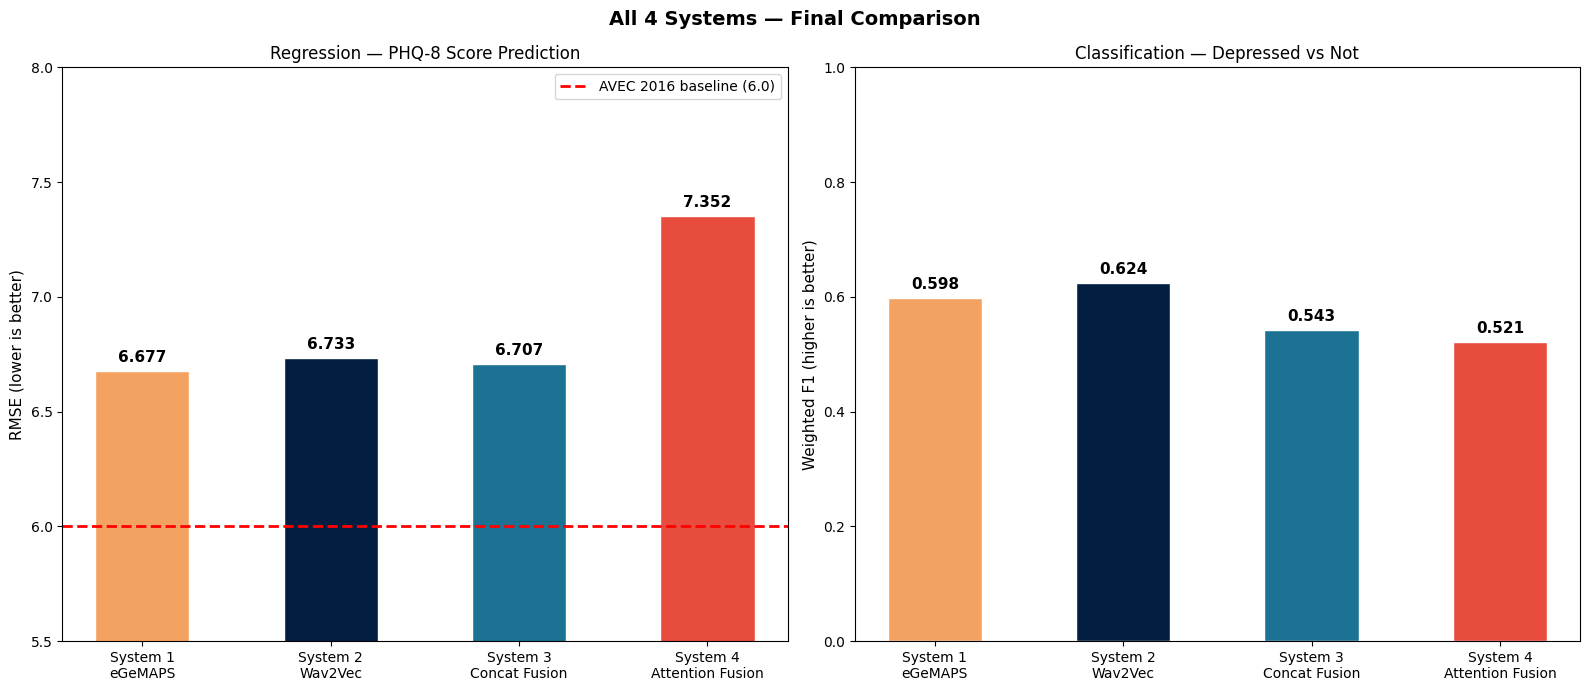

✅ Final 4-system comparison chart saved


In [ ]:
# ── Final 4-system comparison chart ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('All 4 Systems — Final Comparison', fontsize=14, fontweight='bold')

systems = ['System 1\neGeMAPS', 'System 2\nWav2Vec', 'System 3\nConcat Fusion', 'System 4\nAttention Fusion']
rmse_vals = [6.677, 6.733, 6.707, rmse_stacked]
f1_vals   = [0.598, 0.624, 0.543, f1_stacked]
colors_s  = ['#F4A261', '#021E40', '#1C7293', '#E74C3C']

# Regression
bars = axes[0].bar(systems, rmse_vals, color=colors_s, edgecolor='white', width=0.5)
axes[0].axhline(y=6.0, color='red', linestyle='--', linewidth=2, label='AVEC 2016 baseline (6.0)')
axes[0].set_ylabel('RMSE (lower is better)', fontsize=11)
axes[0].set_title('Regression — PHQ-8 Score Prediction', fontsize=12)
axes[0].set_ylim(5.5, 8.0)
axes[0].legend()
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Classification
bars2 = axes[1].bar(systems, f1_vals, color=colors_s, edgecolor='white', width=0.5)
axes[1].set_ylabel('Weighted F1 (higher is better)', fontsize=11)
axes[1].set_title('Classification — Depressed vs Not', fontsize=12)
axes[1].set_ylim(0, 1.0)
for bar, val in zip(bars2, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                 f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{NEXT_STEPS_PATH}/all_4_systems.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final 4-system comparison chart saved")


---
## Section 16 — Save All Results

In [ ]:
import json

# Save tuning results
tuning_summary = {
    "svr_default_rmse":  6.677,
    "svr_tuned_rmse":    round(float(rmse_tuned), 3),
    "svr_best_params":   str(grid_svr.best_params_),
    "lr_default_f1":     0.624,
    "lr_tuned_f1":       round(float(f1_tuned), 3),
    "lr_best_params":    str(grid_lr.best_params_),
    "system4_rmse":      round(float(rmse_stacked), 3),
    "system4_f1":        round(float(f1_stacked), 3),
    "avec_2016_baseline": 6.0,
}
with open(f'{NEXT_STEPS_PATH}/next_steps_summary.json', 'w') as f:
    json.dump(tuning_summary, f, indent=2)

# Save feature importance data
importance_df = pd.DataFrame({
    'feature':    [feature_names[i] for i in top_idx],
    'importance': top_vals,
    'correlation': [np.corrcoef(X1_train[:, i], y_reg_train)[0, 1] for i in top_idx]
})
importance_df.to_csv(f'{NEXT_STEPS_PATH}/feature_importance.csv', index=False)

print("✅ All results saved to Google Drive")
print(f"   Location: {NEXT_STEPS_PATH}")
print()
print("Files saved:")
for f in sorted(os.listdir(NEXT_STEPS_PATH)):
    size = os.path.getsize(f'{NEXT_STEPS_PATH}/{f}')
    print(f"   {f:40s} {size/1024:.0f} KB")


✅ All results saved to Google Drive
   Location: /content/drive/MyDrive/Speech and audio understanding/DAIC-WOZ/next_steps

Files saved:
   all_4_systems.png                        96 KB
   feature_importance.csv                   1 KB
   feature_importance.png                   301 KB
   feature_scatter.png                      192 KB
   hyperparameter_tuning.png                88 KB
   next_steps_summary.json                  0 KB


## ✅ Pipeline Complete!

**What this notebook did:**
1. Installed and imported all required libraries
2. Mounted Google Drive and organized folders
3. Loaded and explored train/dev/test label splits
4. Unzipped all session folders
5. Parsed transcript files to extract participant-only speech
6. Extracted **eGeMAPS features** (88-dim) using openSMILE — System 1
7. Extracted **Wav2Vec 2.0 embeddings** (768-dim) using HuggingFace — System 2
8. Built **fusion features** (856-dim) combining both — System 3
9. Trained and evaluated **SVR, Random Forest, XGBoost** for regression and classification
10. Visualized and saved all results to Google Drive


| Step | What was done | Key result |
|---|---|---|
| **Feature Importance** | Random Forest on 500 trees identified top acoustic features | See feature_importance.png |
| **Hyperparameter Tuning** | GridSearchCV on SVR (regression) and LogReg (classification) | See hyperparameter_tuning.png |
| **System 4 — Stacking Fusion** | Meta-learner combines 6 base model predictions | See all_4_systems.png |
